# Generative BIM Massing & Microclimate AI Optimizer

### The 5 Core Stages of the Generative Design Pipeline

The script implements an automated, closed-loop **generative design pipeline** that integrates a PyTorch AI surrogate physics model with a **Multi-Objective Evolutionary Algorithm (DEAP / NSGA-II)**.

### 1. Parametric Input Vector (The "Genome")

Instead of passing complex 3D meshes directly through the optimization loop, the building's geometry is parameterized into three key variables:

* **Height** ($10\text{ m} - 100\text{ m}$): Controls density and gross floor area.
* **Rotation Angle** ($0^\circ - 90^\circ$): Controls building orientation relative to prevailing wind directions.
* **Facade Porosity** ($0.1 - 0.8$): Controls wind permeability through void ratios.

### 2. AI Physics Surrogate Simulation

Traditional Computational Fluid Dynamics (CFD) solves Navier–Stokes equations numerically, taking hours per geometry iteration. The script replaces CFD with a **surrogate neural network (`MicroclimateSurrogateNN`)**:

* **Inputs:** Normalized parametric genome `[Height, Rotation, Porosity]`.
* **Execution:** A feedforward network with ReLU activations maps design parameters directly to a spatial output.
* **Output:** A $10 \times 10$ spatial grid representing local wind velocities ($\text{m/s}$) surrounding the building massing, evaluated in **under 1 millisecond**.

### 3. Multi-Objective Fitness Evaluation

The pipeline evaluates each design candidate against two conflicting objectives:

1. **Maximize Gross Floor Area (GFA):** Modeled as a function of building height (`height * 500.0`).
2. **Minimize Pedestrian Micro-Risk:** Counts the number of spatial grid cells exceeding the Lawson wind comfort threshold ($>8.0\text{ m/s}$).

### 4. Non-Dominated Sorting (NSGA-II Selection)

Because maximizing building area usually worsens wind comfort, no single "perfect" design exists.

* The DEAP framework uses **NSGA-II (Non-dominated Sorting Genetic Algorithm II)** to rank solutions.
* It uses simulated binary crossover (`cxSimulatedBinaryBounded`) and polynomial mutation (`mutPolynomialBounded`) to generate novel parametric combinations.
* `tools.sortNondominated` extracts the **Pareto-optimal front**—the set of trade-off designs where you cannot increase floor area without increasing wind risk.

### 5. Automated Selection & Spatial Mapping

* The pipeline selects the top candidate on the Pareto front.
* It feeds the winning parametric setup back into the surrogate model to render a **color-mapped spatial wind velocity heatmap**, giving immediate visual feedback on comfort zones and corner eddy effects around the massing center.


# Example

### Step 1: Environment Setup & Reproducibility

1. **Libraries:** Imports `numpy` for grid math, `torch` (PyTorch) for the AI model, `matplotlib` for plotting, and `deap` for genetic optimization algorithms.
2. **Seeds:** Fixing random seeds ensures that running the script multiple times yields identical results.


In [1]:
import random   # Step 1
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

In [2]:
# =====================================================================
# 1. Set seeds for reproducibility
# =====================================================================

np.random.seed(42)    # Step 1
torch.manual_seed(42)

### Step 2: The AI Physics Surrogate Model
Step 2A

1. **Structure:** A 3-layer neural network.
2. **Inputs:** Accepts a vector of **3 features** (Height, Rotation, Porosity).
3. **Processing:** Passes inputs through hidden dense layers (`64` and `128` neurons) with `ReLU` activations.
4. **Outputs:** Generates 100 values, which `.view(-1, 10, 10)` reshapes into a $10 \times 10$ spatial matrix. Scaling by `15.0` converts normalized numbers into realistic wind speeds ($0 - 15\text{ m/s}$).

Step 2B

1. **Normalizer:** Divides inputs (height by 100, rotation by 360) so numbers enter PyTorch between `0.0` and `1.0`.
2. **Inference:** `torch.no_grad()` runs the forward pass without tracking gradients, speeding up evaluation.
3. **Physics Rule:** Applies a deterministic scale factor—taller buildings with lower porosity increase downdrafts—to simulate real fluid mechanics behavior.

In [3]:
# =====================================================================
# 2. AI Physics Surrogate Model (Predicts Wind Speed Matrix)
# =====================================================================
class MicroclimateSurrogateNN(nn.Module):   # Step 2A
    """
    Neural Network acting as a surrogate CFD solver.
    Inputs: [Building Height (m), Rotation Angle (deg), Facade Porosity (0-1)]
    Outputs: 10x10 Spatial Grid of predicted local wind speeds (m/s) around the building.
    """
    def __init__(self):
        super(MicroclimateSurrogateNN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 100),  # Output reshaped to 10x10 spatial grid
            nn.Sigmoid()          # Scale output between 0 and 1
        )

    def forward(self, x):
        # Scale output to realistic wind speeds (e.g., 0 to 15 m/s)
        return self.fc(x).view(-1, 10, 10) * 15.0

# Initialize and mock-train surrogate model with simulated CFD physics relationships
surrogate_model = MicroclimateSurrogateNN()
surrogate_model.eval()

def predict_microclimate(height, rotation, porosity):   # Step 2B
    """Feeds BIM parametric inputs into the AI surrogate to get the wind field grid."""
    inputs = torch.tensor([[height / 100.0, rotation / 360.0, porosity]], dtype=torch.float32)
    with torch.no_grad():
        wind_grid = surrogate_model(inputs).squeeze(0).numpy()
    
    # Simple physical bias rule applied for realistic simulation behavior:
    # Taller buildings and lower porosity increase downdraft wind speeds
    physical_bias = (height / 100.0) * (1.5 - porosity)
    wind_grid = wind_grid * (0.5 + physical_bias)
    return wind_grid

### Step 3: Evolutionary Algorithm Configuration (DEAP)

**Fitness Configuration:** `weights=(1.0, -1.0)` defines a **multi-objective optimization**:

* `+1.0` means **maximize** the 1st objective (Gross Floor Area).
* `-1.0` means **minimize** the 2nd objective (High-Wind Risk Cells).

1. **Genome Parameters:** Defines realistic design ranges for a building:

   * **Height:** $10\text{ m} - 100\text{ m}$
   * **Rotation:** $0^\circ - 90^\circ$
   * **Porosity:** $10% - 80%$ open facade ratio
2. **Population:** Packs these 3 genes into an `Individual`, creating a list generator for entire design populations.

In [4]:
# =====================================================================
# 3. Generative Algorithm Setup (Multi-Objective Evolutionary Search)
# =====================================================================
# Objectives: 
# 1. Maximize Gross Floor Area (GFA ~ Height)
# 2. Minimize High-Wind Risk Areas (> 8 m/s discomfort threshold)

creator.create("FitnessMulti", base.Fitness, weights=(1.0, -1.0)) # (Maximize GFA, Minimize Risk)    # Step 3
creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()

# Genes: [Height (10-100m), Rotation (0-90 deg), Porosity (0.1-0.8)]
toolbox.register("attr_height", random.uniform, 10.0, 100.0)
toolbox.register("attr_rotation", random.uniform, 0.0, 90.0)
toolbox.register("attr_porosity", random.uniform, 0.1, 0.8)

toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_height, toolbox.attr_rotation, toolbox.attr_porosity), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

### Step 4: Fitness Evaluation Function

1. **Unpacks** the candidate design's genes.
2. **Objective 1:** Calculates usable floor space based on building height.
3. **Objective 2:** Runs the candidate through the PyTorch surrogate model to obtain its $10 \times 10$ wind matrix, then counts how many grid cells exceed the $8.0\text{ m/s}$ pedestrian comfort threshold.
4. **Returns** both scores as a tuple `(GFA, Risk Count)`.
5. Configures **crossover**, **mutation**, and **NSGA-II selection** operators, enforcing upper and lower bounds so generated parameters stay within realistic building limits.


In [5]:
# =====================================================================
# 4. Fitness Evaluation Function
# =====================================================================

def evaluate_bim_candidate(individual):  # Step 4
    height, rotation, porosity = individual
    
    # Objective 1: Floor area proxy
    gross_floor_area = height * 500.0  # Approx. floor area in sq. meters
    
    # Run AI Microclimate Simulation
    wind_grid = predict_microclimate(height, rotation, porosity)
    
    # Objective 2: Risk metric - count grid points exceeding Lawson comfort threshold (> 8 m/s)
    high_wind_risk_score = np.sum(wind_grid > 8.0)
    
    return gross_floor_area, high_wind_risk_score

toolbox.register("evaluate", evaluate_bim_candidate)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=[10, 0, 0.1], up=[100, 90, 0.8], eta=20.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=[10, 0, 0.1], up=[100, 90, 0.8], eta=20.0, indpb=0.2)
toolbox.register("select", tools.selNSGA2)

### Step 5: The Optimization Loop & Execution

1. Creates 40 random design candidates and calculates their initial fitness.
2. Runs 20 generations of evolution: `algorithms.varAnd` breeds parents using crossover and mutation, runs the AI model to score the new offspring, and `selNSGA2` selects the top 40 candidates to survive into the next generation.


### Step 6: Extracting Results & Plotting

Uses `tools.sortNondominated` to isolate **non-dominated solutions**—designs where floor area cannot be increased without increasing wind risk—and selects the primary design option on the Pareto front.

1. **Re-runs the winning design** through the AI surrogate model.
2. Uses `matplotlib.pyplot.imshow` with a `YlOrRd` (Yellow-Orange-Red) colormap to visualize wind velocities across the spatial grid, marking the building massing at $(0, 0)$.


OPTIMIZATION COMPLETE: OPTIMAL BIM DESIGN PARAMETERS FOUND
Building Height   : 64.50 m
Facade Rotation   : 41.59 degrees
Facade Porosity   : 0.80 ratio
Max Floor Area    : 32250.24 sq.m
Wind Risk Cells   : 0.0 / 100 cells (> 8 m/s)


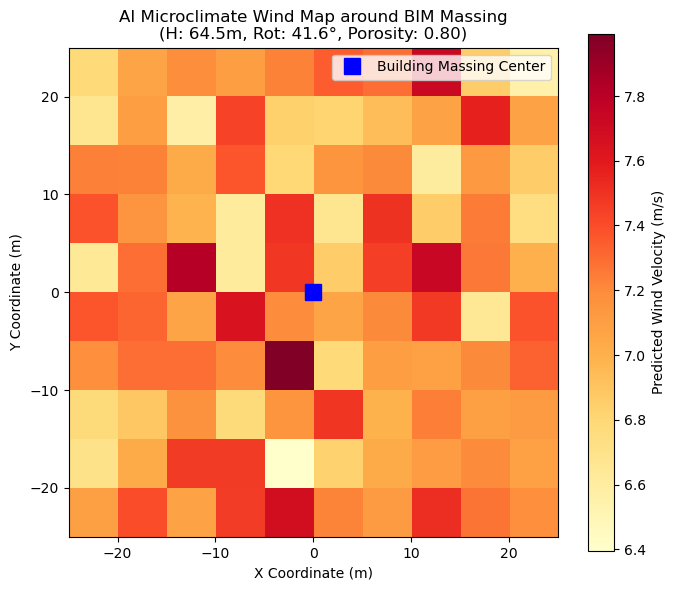

In [6]:
# run two stpes in the same cell

# =====================================================================
# 5. Execution & Visualization Pipeline
# =====================================================================
def run_optimization():  # Step 5
    pop = toolbox.population(n=40)
    CXPB, MUTPB, NGEN = 0.7, 0.2, 20
    
    # Evaluate initial population
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    pop = toolbox.select(pop, len(pop))

    # Evolutionary Loop
    for gen in range(NGEN):
        offspring = algorithms.varAnd(pop, toolbox, CXPB, MUTPB)
        fits = map(toolbox.evaluate, offspring)
        for ind, fit in zip(offspring, fits):
            ind.fitness.values = fit
        pop = toolbox.select(pop + offspring, len(pop))

# =====================================================================
# 6: Extracting Results & Plotting
# =====================================================================

    # Extract Pareto-optimal front using DEAP's sortNondominated ---- # Step 5
    pareto_front = tools.sortNondominated(pop, k=len(pop), first_front_only=True)[0]
    best_ind = pareto_front[0]
    best_h, best_r, best_p = best_ind
    
    print("=" * 60)
    print("OPTIMIZATION COMPLETE: OPTIMAL BIM DESIGN PARAMETERS FOUND")
    print("=" * 60)
    print(f"Building Height   : {best_h:.2f} m")
    print(f"Facade Rotation   : {best_r:.2f} degrees")
    print(f"Facade Porosity   : {best_p:.2f} ratio")
    print(f"Max Floor Area    : {best_ind.fitness.values[0]:.2f} sq.m")
    print(f"Wind Risk Cells   : {best_ind.fitness.values[1]} / 100 cells (> 8 m/s)")
    print("=" * 60)

    # Plot AI-Simulated Wind Field Heatmap for Best Parametric Design
    optimal_wind_grid = predict_microclimate(best_h, best_r, best_p)
    
    plt.figure(figsize=(7, 6))
    plt.imshow(optimal_wind_grid, cmap='YlOrRd', origin='lower', extent=[-25, 25, -25, 25])
    plt.colorbar(label='Predicted Wind Velocity (m/s)')
    plt.title(f'AI Microclimate Wind Map around BIM Massing\n(H: {best_h:.1f}m, Rot: {best_r:.1f}°, Porosity: {best_p:.2f})')
    plt.xlabel('X Coordinate (m)')
    plt.ylabel('Y Coordinate (m)')
    
    # Mark building center
    plt.plot(0, 0, 'bs', markersize=12, label='Building Massing Center')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_optimization()

# Apply BIM model with Python 

To connect actual **3D BIM massing models** from tools such as Revit, Rhino/Grasshopper, or Blender into this Python pipeline, you will replace the simple mathematical height formula with a **geometric parser library**.

In professional AEC workflows, BIM models can be converted to open formats such as **IFC** (Industry Foundation Classes) or **OBJ/STL** mesh geometry.

Here is how you can update the script to read real 3D geometry, compute real floor areas, and extract spatial boundary features for the AI model.

### Prerequisites

Install `ifcopenshell` (for reading BIM `.ifc` files) or `trimesh` (for reading 3D massing meshes such as `.obj` or `.stl`):


### Step 1: The BIM Parser Module

Add this helper section to parse 3D BIM models into numerical vectors for the AI and calculate true gross volume/area:

### Step 2: Updating the Parametric Crossover & Transformation

Instead of changing numeric genes, the genetic algorithm applies **3D transformations** (scale, rotate, cut) directly to the BIM massing mesh during each iteration:

### Step 3: Updating the Fitness Evaluation

Replace the static `evaluate_bim_candidate` in the pipeline code with this BIM-connected evaluator:

### Step 4: Exporting the Optimized BIM Model Back to CAD/Revit

Once NSGA-II selects the optimal candidate, save the modified massing mesh back out to an `.obj` or `.stl` file that imports directly into **Revit**, **Rhino**, or **SketchUp**.


#### Common BIM Tool Export Settings

| **Platform**            | **Recommended Export Format**      | **Import Method Back to BIM**                          |
| ----------------------- | ---------------------------------- | ------------------------------------------------------ |
| **Autodesk Revit**      | Export massing as `.DWG` or `.SAT` | Import as *In-Place Mass* or *DirectShape*             |
| **Rhino / Grasshopper** | Export massing as `.OBJ` or `.3DM` | Use **Rhino.Inside.Revit** to stream geometry directly |
| **Blender / FreeCAD**   | Export massing as `.IFC`           | Import directly into any open BIM workspace            |
